# 🦺 Sistema Inteligente de Verificação de EPIs com YOLOv8

## 📌 Visão geral

Este notebook desenvolve uma aplicação de Visão Computacional para identificar **Equipamentos de Proteção Individual (EPIs)** e sinalizar possíveis ausências desses equipamentos em fotografias de obras.

O projeto utiliza exclusivamente o dataset oficial **Construction-PPE**, documentado e distribuído pela Ultralytics:

🔗 https://docs.ultralytics.com/datasets/detect/construction-ppe

### 🎯 Objetivos

1. Baixar automaticamente o dataset oficial.
2. Treinar um modelo YOLOv8 Nano por transferência de aprendizagem.
3. Avaliar o modelo em imagens de teste não usadas no treinamento.
4. Permitir o envio de fotografias externas.
5. Gerar imagens anotadas e um relatório de possíveis não conformidades.

> ⚠️ O sistema é um protótipo acadêmico de triagem visual. Ele não substitui inspeções de segurança realizadas por profissionais qualificados.

# ⚙️ Passo 1: Configuração do ambiente

### 🎯 Objetivo da etapa

Instalar as bibliotecas e preparar o Google Colab para o treinamento.

Antes de executar, ative a GPU em:

`Ambiente de execução → Alterar tipo de ambiente de execução → T4 GPU`

### 🛠️ Tecnologias

- **Ultralytics:** treinamento e inferência com YOLOv8.
- **OpenCV:** leitura, anotação e recorte das imagens.
- **PyTorch:** processamento da rede neural.
- **Pandas:** criação dos relatórios.

In [ ]:
!pip install -q ultralytics opencv-python-headless pandas pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import math
import shutil
import torch
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from ultralytics import YOLO, settings

DISPOSITIVO = 0 if torch.cuda.is_available() else 'cpu'
PASTA_PROJETO = Path('/content/projeto_epi')
PASTA_DATASETS = Path('/content/datasets')

PASTA_PROJETO.mkdir(parents=True, exist_ok=True)
PASTA_DATASETS.mkdir(parents=True, exist_ok=True)
settings.update({'datasets_dir': str(PASTA_DATASETS)})

print('PyTorch:', torch.__version__)
print('GPU disponível:', torch.cuda.is_available())
print('Dispositivo selecionado:', DISPOSITIVO)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch: 2.11.0+cu128
GPU disponível: True
Dispositivo selecionado: 0
GPU: Tesla T4


# 📥 Passo 2: Download do dataset oficial Construction-PPE

### 🎯 Objetivo da etapa

Baixar diretamente da infraestrutura da Ultralytics o dataset utilizado no projeto. Nenhum arquivo precisa ser preparado no computador.

### 📊 Estrutura oficial

| Divisão | Imagens | Finalidade |
|---|---:|---|
| Treinamento | 1.132 | Aprendizagem dos parâmetros |
| Validação | 143 | Acompanhamento durante o treinamento |
| Teste | 141 | Avaliação final independente |
| **Total** | **1.416** | — |

O dataset possui **11.521 bounding boxes revisadas** e 11 classes. O download oficial tem aproximadamente 178 MB.

### 🏷️ Classes

`helmet`, `gloves`, `vest`, `boots`, `goggles`, `none`, `Person`, `no_helmet`, `no_goggle`, `no_gloves` e `no_boots`.

Fonte: https://docs.ultralytics.com/datasets/detect/construction-ppe

In [ ]:
from ultralytics.data.utils import check_det_dataset

# O nome abaixo corresponde ao YAML oficial incluído no pacote Ultralytics.
NOME_DATASET_OFICIAL = 'construction-ppe.yaml'

informacoes_dataset = check_det_dataset(
    NOME_DATASET_OFICIAL,
    autodownload=True
)

print('Dataset baixado e validado pela Ultralytics!')
print('Treino:', informacoes_dataset['train'])
print('Validação:', informacoes_dataset['val'])
print('Teste:', informacoes_dataset['test'])
print('Classes:', informacoes_dataset['names'])


WARNING ⚠️ Dataset 'construction-ppe.yaml' images not found, missing path '/content/datasets/construction-ppe/images/val'
Unzipping /content/datasets/construction-ppe.zip to /content/datasets/construction-ppe...: 100% ━━━━━━━━━━━━ 2852/2852 795.2files/s 3.6s
Dataset download success ✅ (4.9s), saved to /content/datasets

Dataset baixado e validado pela Ultralytics!
Treino: /content/datasets/construction-ppe/images/train
Validação: /content/datasets/construction-ppe/images/val
Teste: /content/datasets/construction-ppe/images/test
Classes: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}


# 🔎 Passo 3: Conferência das divisões do dataset

### 🎯 Objetivo da etapa

Confirmar que as imagens foram baixadas e que as três divisões estão disponíveis antes do treinamento.

Essa validação também serve como evidência de que o notebook está usando o dataset Construction-PPE, e não uma base externa com nome semelhante.

In [ ]:
EXTENSOES = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def obter_pastas(valor):
    valores = valor if isinstance(valor, list) else [valor]
    return [Path(str(item)) for item in valores]

def contar_imagens(valor):
    total = 0
    for pasta in obter_pastas(valor):
        if pasta.exists():
            total += sum(
                1 for arquivo in pasta.rglob('*')
                if arquivo.suffix.lower() in EXTENSOES
            )
    return total

contagens = {
    'Treinamento': contar_imagens(informacoes_dataset['train']),
    'Validação': contar_imagens(informacoes_dataset['val']),
    'Teste': contar_imagens(informacoes_dataset['test'])
}

display(pd.DataFrame(
    contagens.items(),
    columns=['Divisão', 'Quantidade de imagens']
))

if contagens != {'Treinamento': 1132, 'Validação': 143, 'Teste': 141}:
    print('Aviso: as contagens diferem da versão documentada do dataset.')
else:
    print('Contagens compatíveis com a documentação oficial.')

,Divisão,Quantidade de imagens
0,Treinamento,1132
1,Validação,143
2,Teste,141


Contagens compatíveis com a documentação oficial.


# 🧠 Passo 4: Treinamento do YOLOv8 Nano

### 🎯 Objetivo da etapa

Realizar o ajuste fino de um modelo pré-treinado para reconhecer EPIs e possíveis ausências.

### 🤖 Por que YOLOv8 Nano?

O `yolov8n.pt` é leve, rápido e adequado à GPU T4 do Colab. O treinamento não começa do zero: o modelo já aprendeu representações visuais gerais e será especializado no contexto de segurança do trabalho.

### 📊 Configuração

- 40 épocas, com interrupção antecipada;
- resolução 640 × 640;
- batch automático para aproveitar a GPU;
- conjunto oficial de validação durante o treinamento.

In [ ]:
modelo_base = YOLO('yolov8n.pt')

resultado_treinamento = modelo_base.train(
    data=NOME_DATASET_OFICIAL,
    epochs=40,
    imgsz=640,
    batch=16,
    device=DISPOSITIVO,
    workers=2,
    patience=10,
    pretrained=True,
    seed=42,
    plots=True,
    project=str(PASTA_PROJETO / 'resultados'),
    name='yolov8n_construction_ppe',
    exist_ok=True,
    verbose=True
)

CAMINHO_BEST = (
    PASTA_PROJETO / 'resultados' / 'yolov8n_construction_ppe'
    / 'weights' / 'best.pt'
)

if not CAMINHO_BEST.exists():
    raise FileNotFoundError(f'Pesos não encontrados: {CAMINHO_BEST}')

print('Treinamento concluído!')
print('Melhor modelo:', CAMINHO_BEST)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_construction_ppe, nbs=64, nms=Fal

# ☁️ Passo 5: Preservação do modelo no Google Drive

### 🎯 Objetivo da etapa

Copiar imediatamente o `best.pt` para o Google Drive. Os arquivos armazenados em `/content` são apagados quando o Colab reinicia.

O modelo será salvo em:

`Meu Drive/modelos_yolo/yolov8n_construction_ppe_best.pt`

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

PASTA_DRIVE = Path('/content/drive/MyDrive/modelos_yolo')
PASTA_DRIVE.mkdir(parents=True, exist_ok=True)

CAMINHO_MODELO_DRIVE = (
    PASTA_DRIVE / 'yolov8n_construction_ppe_best.pt'
)

shutil.copy2(CAMINHO_BEST, CAMINHO_MODELO_DRIVE)

print('Modelo salvo permanentemente!')
print(CAMINHO_MODELO_DRIVE)

Mounted at /content/drive
Modelo salvo permanentemente!
/content/drive/MyDrive/modelos_yolo/yolov8n_construction_ppe_best.pt


# 🧪 Passo 6: Avaliação no conjunto oficial de teste

### 🎯 Objetivo da etapa

Avaliar o melhor modelo nas 141 imagens reservadas para teste. Essas imagens não foram utilizadas para ajustar os parâmetros.

### 📈 Métricas

- **Precision:** proporção das detecções que estavam corretas.
- **Recall:** proporção dos objetos reais encontrados.
- **mAP50:** qualidade média com IoU de 50%.
- **mAP50-95:** medida mais rigorosa, calculada em diferentes IoUs.

In [ ]:
modelo_epi = YOLO(str(CAMINHO_BEST))

metricas_teste = modelo_epi.val(
    data=NOME_DATASET_OFICIAL,
    split='test',
    imgsz=640,
    batch=16,
    device=DISPOSITIVO,
    plots=True
)

resumo_metricas = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'mAP50', 'mAP50-95'],
    'Resultado': [
        metricas_teste.box.mp,
        metricas_teste.box.mr,
        metricas_teste.box.map50,
        metricas_teste.box.map
    ]
})

display(resumo_metricas.style.format({'Resultado': '{:.4f}'}))

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2464.8±1475.7 MB/s, size: 183.6 KB)
val: Scanning /content/datasets/construction-ppe/labels/test... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 2.1Kit/s 0.1s
val: New cache created: /content/datasets/construction-ppe/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.1it/s 4.2s
                   all        141       1251      0.606      0.533      0.555      0.273
                helmet        110        192      0.857      0.891      0.924      0.511
                gloves         75        163        0.8      0.755      0.788      0.387
                  vest        111        178      0.799      0.882      0.903       0.57
                 boots         75        211      

,Métrica,Resultado
0,Precision,0.6056
1,Recall,0.5330
2,mAP50,0.5550
3,mAP50-95,0.2733


## 📊 Análise e interpretação das métricas do modelo

### 🎯 Objetivo da etapa

Interpretar os resultados obtidos pelo YOLOv8 no conjunto oficial de teste e identificar os pontos fortes e as limitações do modelo.

### 📌 Significado das métricas

1. **Precision (Precisão):** indica quantas detecções realizadas pelo modelo estavam corretas. Uma precisão baixa representa muitos falsos alarmes.

2. **Recall (Revocação):** indica quantos dos objetos existentes nas imagens foram encontrados. Em uma aplicação de segurança, essa métrica é especialmente importante, pois um Recall baixo significa que determinados EPIs ou situações de risco não foram identificados.

3. **mAP50:** mede a qualidade geral das detecções considerando uma sobreposição mínima de 50% entre a caixa prevista e a caixa verdadeira.

4. **mAP50-95:** é uma avaliação mais rigorosa, calculada com diferentes níveis de sobreposição, entre 50% e 95%. Por isso, normalmente apresenta um resultado menor que o mAP50.

### 🦺 Interpretação no contexto de segurança

Para a verificação de EPIs, falsos negativos podem ser mais preocupantes que falsos positivos. Por exemplo, deixar de identificar uma pessoa sem capacete pode representar um risco maior do que gerar um alerta adicional.

Por isso, é importante observar principalmente o **Recall das classes que representam ausência de proteção**, como `no_helmet`, `no_gloves`, `no_goggle` e `no_boots`.

> Este modelo é um protótipo acadêmico. Seus resultados não substituem a inspeção realizada por um profissional de segurança do trabalho.

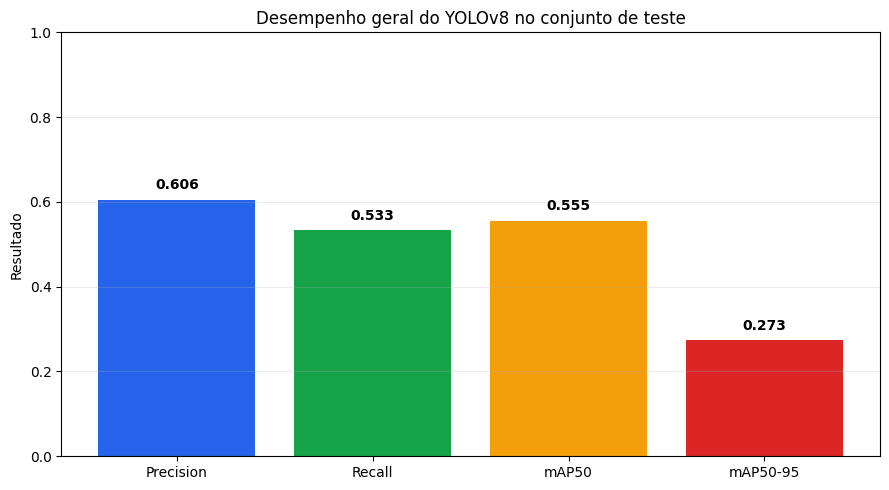

,Classe,Precision,Recall,mAP50,mAP50-95
0,helmet,0.857,0.891,0.924,0.511
1,vest,0.799,0.882,0.903,0.570
2,Person,0.790,0.818,0.837,0.493
3,gloves,0.800,0.755,0.788,0.387
4,goggles,0.736,0.769,0.770,0.323
5,boots,0.707,0.720,0.753,0.397
6,none,0.479,0.492,0.487,0.164
7,no_goggle,0.535,0.140,0.206,0.064
8,no_gloves,0.379,0.172,0.195,0.045
9,no_helmet,0.352,0.203,0.184,0.042


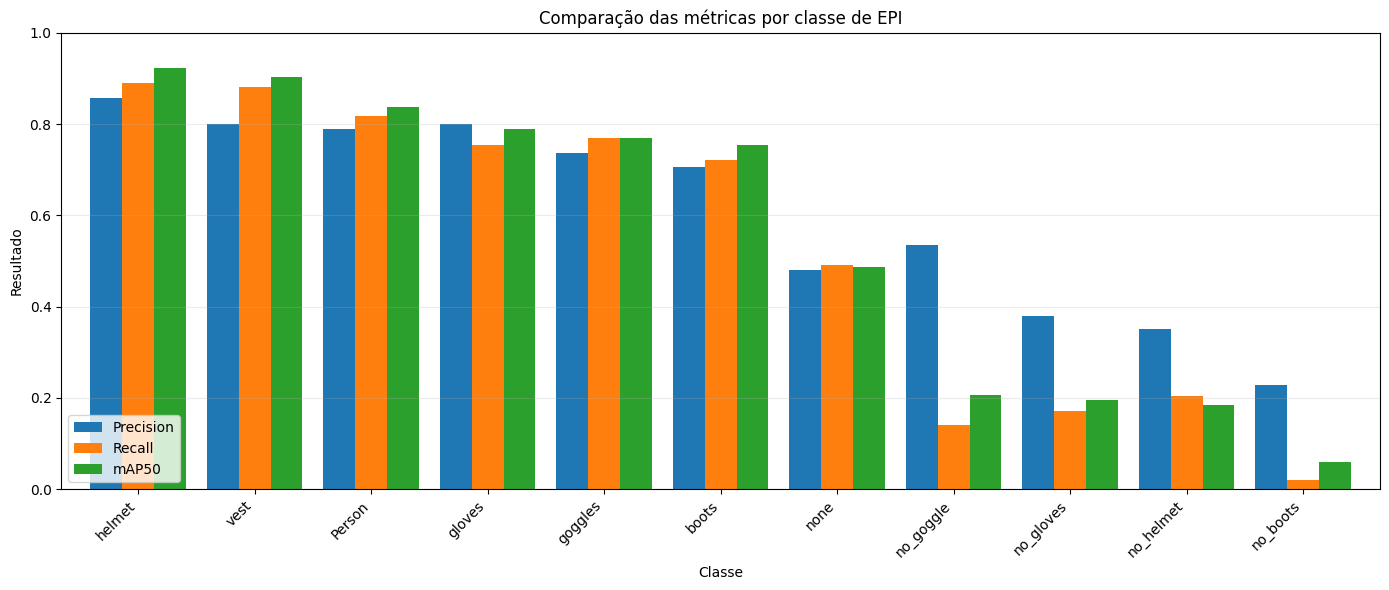


RESUMO DA AVALIAÇÃO
-------------------------------------------------------
Precision geral: 60.6%
Recall geral: 53.3%
mAP50: 55.5%
mAP50-95: 27.3%

Classes com menor Recall:
- no_boots: 2.0%
- no_goggle: 14.0%
- no_gloves: 17.2%

Essas classes precisam de atenção, pois apresentam maior dificuldade de detecção no conjunto de teste.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. GRÁFICO DAS MÉTRICAS GERAIS
# ==========================================================

valores_gerais = [
    float(metricas_teste.box.mp),
    float(metricas_teste.box.mr),
    float(metricas_teste.box.map50),
    float(metricas_teste.box.map)
]

nomes_metricas = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

cores = ["#2563EB", "#16A34A", "#F59E0B", "#DC2626"]

plt.figure(figsize=(9, 5))

barras = plt.bar(
    nomes_metricas,
    valores_gerais,
    color=cores
)

plt.title("Desempenho geral do YOLOv8 no conjunto de teste")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)

for barra, valor in zip(barras, valores_gerais):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.025,
        f"{valor:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ==========================================================
# 2. MÉTRICAS SEPARADAS POR CLASSE
# ==========================================================

indices_classes = metricas_teste.box.ap_class_index.astype(int)

metricas_por_classe = pd.DataFrame({
    "Classe": [
        modelo_epi.names[indice]
        for indice in indices_classes
    ],
    "Precision": metricas_teste.box.p,
    "Recall": metricas_teste.box.r,
    "mAP50": metricas_teste.box.ap50,
    "mAP50-95": metricas_teste.box.ap
})

metricas_por_classe = metricas_por_classe.sort_values(
    by="mAP50",
    ascending=False
).reset_index(drop=True)

display(
    metricas_por_classe.style
    .format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "mAP50": "{:.3f}",
        "mAP50-95": "{:.3f}"
    })
    .background_gradient(
        subset=["Recall"],
        cmap="RdYlGn",
        vmin=0,
        vmax=1
    )
)


# ==========================================================
# 3. GRÁFICO COMPARATIVO POR CLASSE
# ==========================================================

metricas_por_classe.set_index("Classe")[
    ["Precision", "Recall", "mAP50"]
].plot(
    kind="bar",
    figsize=(14, 6),
    width=0.82
)

plt.title("Comparação das métricas por classe de EPI")
plt.ylabel("Resultado")
plt.xlabel("Classe")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


# ==========================================================
# 4. CONCLUSÃO AUTOMÁTICA
# ==========================================================

piores_classes = metricas_por_classe.nsmallest(
    3,
    "Recall"
)[["Classe", "Recall"]]

print("\nRESUMO DA AVALIAÇÃO")
print("-" * 55)

print(
    f"Precision geral: {metricas_teste.box.mp:.1%}"
)

print(
    f"Recall geral: {metricas_teste.box.mr:.1%}"
)

print(
    f"mAP50: {metricas_teste.box.map50:.1%}"
)

print(
    f"mAP50-95: {metricas_teste.box.map:.1%}"
)

print("\nClasses com menor Recall:")

for _, linha in piores_classes.iterrows():
    print(
        f"- {linha['Classe']}: "
        f"{linha['Recall']:.1%}"
    )

print(
    "\nEssas classes precisam de atenção, pois apresentam "
    "maior dificuldade de detecção no conjunto de teste."
)

## 💬 O que os resultados nos mostram?

De forma simples, o modelo apresentou um desempenho **razoável para um protótipo acadêmico**, mas ainda possui limitações importantes.

### ✅ O que o modelo reconhece melhor?

O modelo teve mais facilidade para identificar os equipamentos que estão presentes na imagem:

- `helmet`: capacete;
- `vest`: colete de segurança;
- `gloves`: luvas;
- `goggles`: óculos de proteção;
- `boots`: botas.

O capacete apresentou o melhor resultado, com **mAP50 de 92,4%** e **Recall de 89,1%**. Isso significa que o modelo encontrou a maioria dos capacetes presentes nas imagens e realizou detecções geralmente corretas.

O colete também apresentou um resultado positivo, com **mAP50 de 90,3%** e **Recall de 88,2%**.

### ⚠️ Onde o modelo encontrou mais dificuldade?

As classes que representam a ausência de equipamentos tiveram resultados bem menores:

- `no_goggle`: pessoa sem óculos de proteção;
- `no_gloves`: pessoa sem luvas;
- `no_helmet`: pessoa sem capacete;
- `no_boots`: pessoa sem botas.

A maior dificuldade foi observada na classe `no_boots`, que apresentou **Recall de apenas 2%**. Isso significa que, de cada 100 situações em que uma pessoa estava sem botas, o modelo identificou aproximadamente 2.

A classe `no_helmet` também merece atenção, pois teve **Recall de 20,3%**. Em uma aplicação real, isso seria preocupante, já que muitas pessoas sem capacete poderiam passar sem gerar um alerta.

### 🤔 Por que essa diferença acontece?

É mais fácil para o modelo aprender a aparência de um objeto visível, como um capacete ou colete, do que identificar a **ausência** desse objeto.

Além disso, algumas classes podem possuir:

- menos imagens disponíveis para treinamento;
- objetos pequenos ou parcialmente escondidos;
- diferenças de iluminação e ângulo;
- exemplos visualmente parecidos;
- desequilíbrio na quantidade de objetos de cada classe.

### 📊 Resultado geral

O modelo alcançou:

- **Precision:** 60,6%;
- **Recall:** 53,3%;
- **mAP50:** 55,5%;
- **mAP50-95:** 27,3%.

Esses resultados mostram que o modelo conseguiu aprender os padrões principais do dataset, mas ainda não é confiável o suficiente para realizar sozinho uma fiscalização de segurança.

### 📝 Conclusão da análise

O YOLOv8 apresentou bons resultados na identificação dos equipamentos presentes, principalmente capacetes e coletes. Entretanto, teve dificuldade para reconhecer situações em que os equipamentos estavam ausentes.

Para melhorar o sistema, seria necessário aumentar a quantidade de exemplos das classes `no_helmet`, `no_gloves`, `no_goggle` e `no_boots`, revisar as anotações e realizar novos treinamentos.

> Portanto, o sistema deve ser considerado uma ferramenta de apoio à inspeção, e não um substituto para o profissional de segurança do trabalho.

# 📁 Passo 7: Preparação da pasta para fotos externas

### 🎯 Objetivo da etapa

Criar uma pasta para fotografias escolhidas pelo aluno ou pelo professor.

Depois de executar a célula:

1. abra o ícone de pasta na lateral esquerda;
2. abra `/content/fotos_para_avaliacao`;
3. envie imagens JPG, PNG ou WEBP;
4. execute o passo seguinte.

Essas imagens externas permitem uma avaliação visual da generalização, mas não geram mAP porque não possuem anotações verdadeiras.

In [ ]:
from pathlib import Path

PASTA_UPLOAD = Path('/content/fotos_para_avaliacao')
PASTA_SAIDA = Path('/content/resultados_avaliacao_epi')

PASTA_UPLOAD.mkdir(parents=True, exist_ok=True)
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

print('Pasta pronta para receber fotografias!')
print(PASTA_UPLOAD)

Pasta pronta para receber fotografias!
/content/fotos_para_avaliacao


# 📁 Passo Extra

Como reiniciei o Colab, tenho que carregar o modelo que salvei

In [9]:
# Instala/importa o YOLO.
try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

from pathlib import Path
from google.colab import drive

# Conecta o Drive, caso ainda não esteja conectado.
drive.mount('/content/drive')

CAMINHO_MODELO = Path(
    '/content/drive/MyDrive/modelos_yolo/yolov8n_construction_ppe_best.pt'
)

if not CAMINHO_MODELO.exists():
    raise FileNotFoundError(
        f'Modelo não encontrado em: {CAMINHO_MODELO}'
    )

modelo_epi = YOLO(str(CAMINHO_MODELO))

print('✅ Modelo carregado com sucesso!')
print('Caminho:', CAMINHO_MODELO)
print('Classes:', modelo_epi.names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelo carregado com sucesso!
Caminho: /content/drive/MyDrive/modelos_yolo/yolov8n_construction_ppe_best.pt
Classes: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}


# 🦺 Passo 8: Análise de EPIs em fotografias externas

### 🎯 Objetivo da etapa

Detectar pessoas, equipamentos presentes e indícios de equipamentos ausentes.

### 📋 Resultados produzidos

- fotografias com bounding boxes;
- tabela com classe, confiança e coordenadas;
- resumo de possíveis não conformidades;
- arquivo CSV;
- ZIP com os resultados.

> As classes `no_helmet`, `no_goggle`, `no_gloves` e `no_boots` são tratadas como **indícios**, pois uma decisão de conformidade exige contexto e inspeção humana.

Dispositivo: 0
Confiança mínima: 0.25
Classes de alerta: {'no_gloves', 'no_goggle', 'no_boots', 'no_helmet'}
7 fotografia(s) processada(s).
29 detecção(ões) registrada(s).
Resumo por classe:


,classe,quantidade
0,Person,10
1,helmet,8
2,vest,5
3,none,4
4,gloves,1
5,boots,1


Possíveis não conformidades: 0


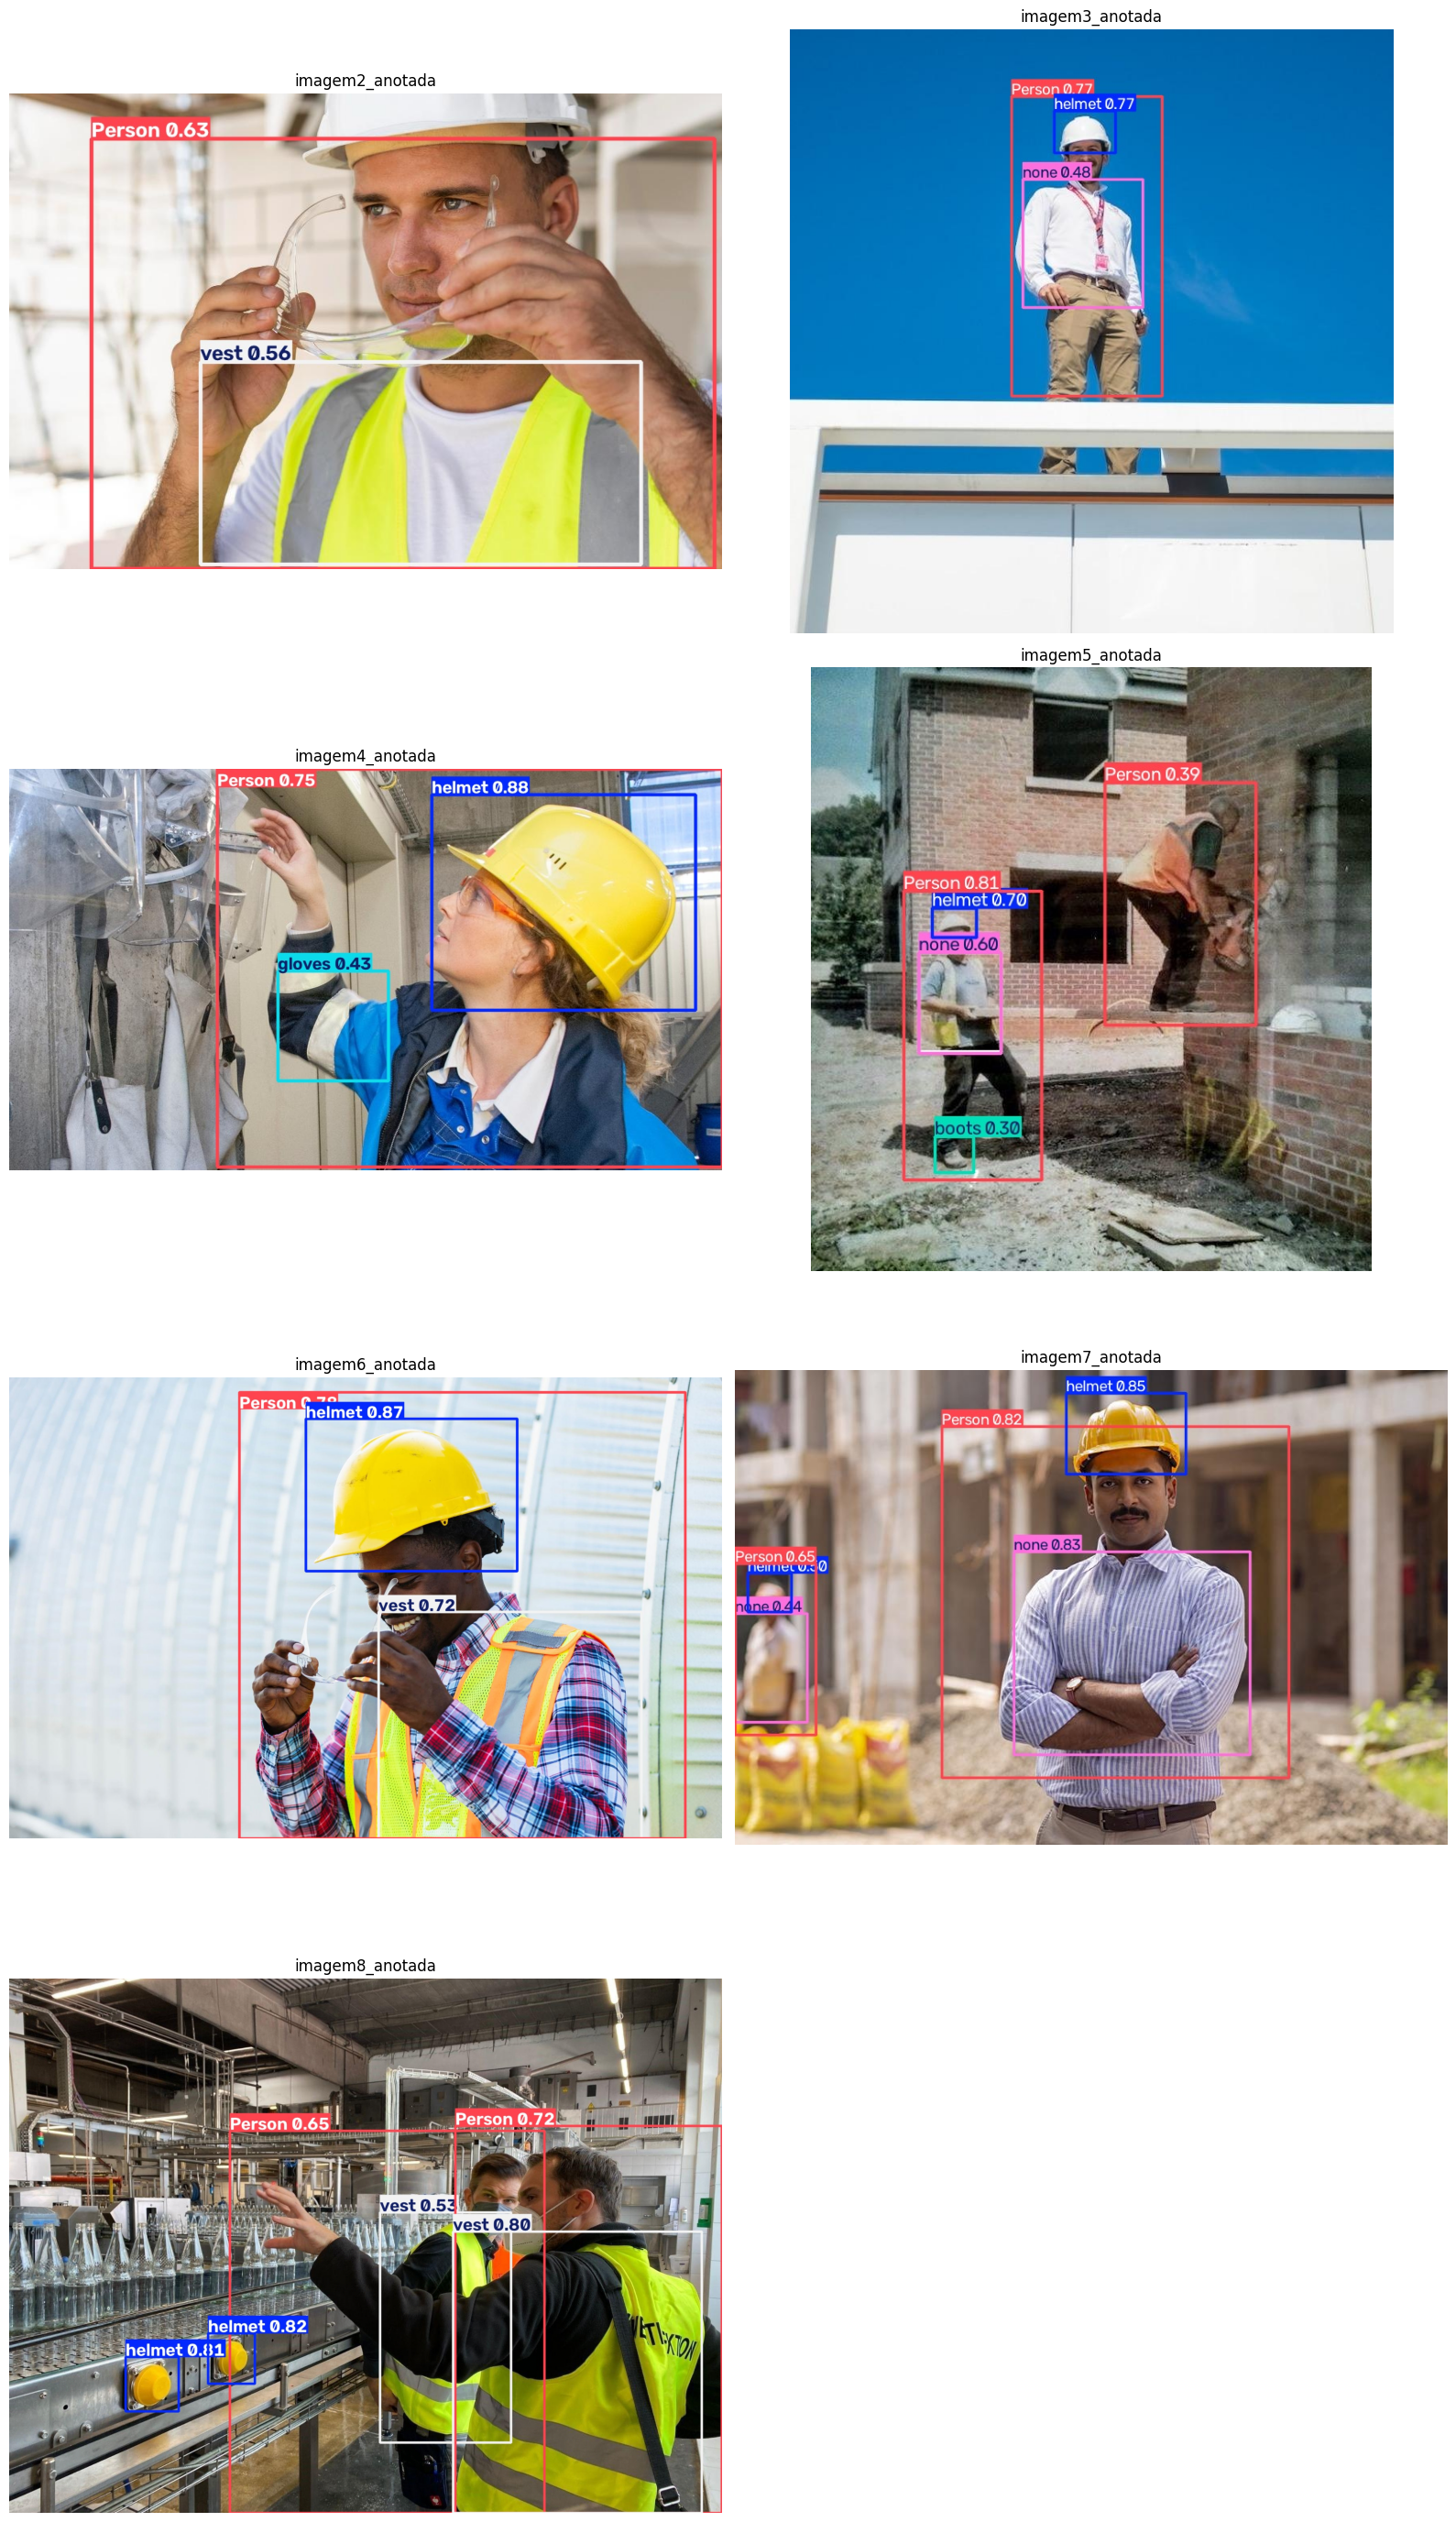

In [13]:
import torch

# Usa GPU quando disponível; caso contrário, utiliza CPU.
DISPOSITIVO = 0 if torch.cuda.is_available() else 'cpu'

# Confiança mínima para aceitar uma detecção.
CONFIANCA_MINIMA = 0.25

# Classes que representam possíveis situações de não conformidade.
CLASSES_ALERTA = {
    'no_helmet',
    'no_goggle',
    'no_gloves',
    'no_boots'
}

print('Dispositivo:', DISPOSITIVO)
print('Confiança mínima:', CONFIANCA_MINIMA)
print('Classes de alerta:', CLASSES_ALERTA)


import shutil
import math
import cv2
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display


# Localiza as fotografias enviadas manualmente.
EXTENSOES_UPLOAD = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
fotos = sorted([
    arquivo for arquivo in PASTA_UPLOAD.iterdir()
    if arquivo.is_file() and arquivo.suffix.lower() in EXTENSOES_UPLOAD
])

if not fotos:
    raise ValueError('Envie pelo menos uma fotografia para a pasta de avaliação.')

if PASTA_SAIDA.exists():
    shutil.rmtree(PASTA_SAIDA)

PASTA_ANOTADAS = PASTA_SAIDA / 'imagens_anotadas'
PASTA_ANOTADAS.mkdir(parents=True, exist_ok=True)

CLASSES_ALERTA = {'no_helmet', 'no_goggle', 'no_gloves', 'no_boots'}
CONFIANCA_MINIMA = 0.30
registros = []
imagens_anotadas = []

for caminho_foto in fotos:
    imagem = cv2.imread(str(caminho_foto))
    if imagem is None:
        print('Imagem ignorada:', caminho_foto.name)
        continue

    resultado = modelo_epi.predict(
        source=imagem,
        conf=CONFIANCA_MINIMA,
        imgsz=640,
        device=DISPOSITIVO,
        verbose=False
    )[0]

    caminho_anotada = PASTA_ANOTADAS / f'{caminho_foto.stem}_anotada.jpg'
    cv2.imwrite(str(caminho_anotada), resultado.plot())
    imagens_anotadas.append(caminho_anotada)

    if resultado.boxes is not None:
        boxes = resultado.boxes.xyxy.cpu().numpy()
        confiancas = resultado.boxes.conf.cpu().numpy()
        classes = resultado.boxes.cls.cpu().numpy().astype(int)

        for box, confianca, id_classe in zip(boxes, confiancas, classes):
            nome_classe = modelo_epi.names[id_classe]
            x1, y1, x2, y2 = map(int, box)
            registros.append({
                'imagem': caminho_foto.name,
                'classe': nome_classe,
                'confianca': round(float(confianca), 4),
                'possivel_nao_conformidade': nome_classe in CLASSES_ALERTA,
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2
            })

tabela = pd.DataFrame(registros)
CAMINHO_CSV = PASTA_SAIDA / 'relatorio_epi.csv'
tabela.to_csv(CAMINHO_CSV, index=False, encoding='utf-8-sig')

print(f'{len(fotos)} fotografia(s) processada(s).')
print(f'{len(tabela)} detecção(ões) registrada(s).')

if not tabela.empty:
    print('Resumo por classe:')
    display(tabela['classe'].value_counts().rename_axis('classe').reset_index(name='quantidade'))

    alertas = tabela[tabela['possivel_nao_conformidade']]
    print(f'Possíveis não conformidades: {len(alertas)}')
    if not alertas.empty:
        display(alertas)

# Exibe todas as imagens anotadas.
colunas = 2
linhas = math.ceil(len(imagens_anotadas) / colunas)
plt.figure(figsize=(16, 7 * linhas))
for indice, caminho in enumerate(imagens_anotadas, start=1):
    imagem_rgb = cv2.cvtColor(cv2.imread(str(caminho)), cv2.COLOR_BGR2RGB)
    plt.subplot(linhas, colunas, indice)
    plt.imshow(imagem_rgb)
    plt.title(caminho.stem)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 📦 Passo 9: Compactação e download

### 🎯 Objetivo da etapa

Compactar as imagens anotadas e o relatório CSV para facilitar a entrega e a apresentação.

In [14]:
from google.colab import files

CAMINHO_ZIP_BASE = Path('/content/resultado_final_epi')
CAMINHO_ZIP = Path('/content/resultado_final_epi.zip')

if CAMINHO_ZIP.exists():
    CAMINHO_ZIP.unlink()

shutil.make_archive(
    str(CAMINHO_ZIP_BASE),
    'zip',
    root_dir=str(PASTA_SAIDA)
)

print('Arquivo preparado:', CAMINHO_ZIP)
files.download(str(CAMINHO_ZIP))

Arquivo preparado: /content/resultado_final_epi.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ✅ Conclusão

O projeto implementou um pipeline completo de Visão Computacional:

1. download automático de um dataset oficial da Ultralytics;
2. treinamento do YOLOv8 por transferência de aprendizagem;
3. preservação do modelo no Google Drive;
4. avaliação quantitativa no conjunto oficial de teste;
5. inferência em fotografias externas;
6. geração de relatório de possíveis não conformidades.

### ⚠️ Limitações

O desempenho pode variar com iluminação, distância, oclusão e ângulo da câmera. Uma detecção de equipamento ausente representa um indício visual e deve ser confirmada por inspeção humana.